# Python Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Import data


In [2]:
col_types = {
    "cough": float,
    "fever": float,
    "sore_throat": float,
    "shortness_of_breath": float,
    "head_ache": float,
    "corona_result": str,
    "age_60_and_above": str,
    "gender": str,
    "test_indication": str,
}
df = pd.read_csv(
    "data/corona_tested_individuals_ver_006.english.csv",
    dtype=col_types,
    parse_dates=["test_date"],
)

In [3]:
df

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
...,...,...,...,...,...,...,...,...,...,...
278843,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278844,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278845,2020-03-11,0.0,0.0,0.0,0.0,0.0,positive,NaN,NaN,Contact with confirmed
278846,2020-03-11,0.0,0.0,0.0,0.0,0.0,other,NaN,NaN,Other


# Analyse Data


In [4]:
df.describe()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache
count,278848,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000
mean,2020-04-10 11:50:32.361716480,0.151574,0.078077,0.006907,0.005655,0.008657
min,2020-03-11 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-04-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2020-04-21 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
max,2020-04-30 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.358608,0.268294,0.082821,0.074990,0.092640


In [5]:
df.describe(include="O")

,corona_result,age_60_and_above,gender,test_indication
count,278848,151528,259285,278848
unique,3,2,2,3
top,negative,No,female,Other
freq,260227,125703,130158,242741


In [6]:
for col in df.columns:
    print(df[col].value_counts(dropna=False, normalize=True), "\n")

test_date
2020-04-20    0.039165
2020-04-19    0.036575
2020-04-22    0.034592
2020-04-21    0.034513
2020-04-16    0.032771
2020-04-23    0.031358
2020-04-01    0.031035
2020-04-13    0.030214
2020-04-02    0.029364
2020-04-03    0.028973
2020-04-17    0.027416
2020-04-05    0.026929
2020-04-30    0.026226
2020-04-27    0.026193
2020-04-15    0.025638
2020-03-31    0.025584
2020-04-24    0.025204
2020-03-26    0.023895
2020-04-14    0.023565
2020-04-28    0.022715
2020-04-18    0.022668
2020-04-26    0.021987
2020-04-12    0.021460
2020-03-27    0.021384
2020-04-07    0.021270
2020-03-30    0.021212
2020-04-10    0.020362
2020-03-28    0.020090
2020-03-25    0.019706
2020-04-06    0.019251
2020-03-29    0.018924
2020-04-04    0.018451
2020-04-25    0.018117
2020-03-24    0.016981
2020-04-09    0.016278
2020-04-11    0.015568
2020-04-29    0.015274
2020-04-08    0.014553
2020-03-22    0.012785
2020-03-23    0.012530
2020-03-19    0.008044
2020-03-18    0.007140
2020-03-20    0.006706
2

In [7]:
# for col in df.columns[1:]:
#     sns.countplot(data=df, x=col, hue="corona_result")
#     plt.show()

# Clean Data


In [8]:
# Drop date column since it is not relevant for modeling
df = df.drop(columns=["test_date"])

# Drop rows with missing target variable
df = df[df["corona_result"] != "other"]

# Set target variable to boolean
df["corona_result"] = df["corona_result"].map({"positive": True, "negative": False})

In [9]:
# Set data types

df["cough"] = df["cough"].astype("category")
df["fever"] = df["fever"].astype("category")
df["sore_throat"] = df["sore_throat"].astype("category")
df["shortness_of_breath"] = df["shortness_of_breath"].astype("category")
df["head_ache"] = df["head_ache"].astype("category")
df["corona_result"] = df["corona_result"].astype("bool")
df["age_60_and_above"] = df["age_60_and_above"].astype("category")
df["gender"] = df["gender"].astype("category")
df["test_indication"] = df["test_indication"].astype("category")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   cough                274704 non-null  category
 1   fever                274704 non-null  category
 2   sore_throat          274955 non-null  category
 3   shortness_of_breath  274955 non-null  category
 4   head_ache            274955 non-null  category
 5   corona_result        274956 non-null  bool    
 6   age_60_and_above     149292 non-null  category
 7   gender               255911 non-null  category
 8   test_indication      274956 non-null  category
dtypes: bool(1), category(8)
memory usage: 4.5 MB


# Train Test Split


In [11]:
X = df.drop("corona_result", axis=1)
y = df["corona_result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [12]:
y.value_counts(normalize=True)

corona_result
False    0.946431
True     0.053569
Name: proportion, dtype: float64

In [13]:
y_train.value_counts(normalize=True)

corona_result
False    0.94643
True     0.05357
Name: proportion, dtype: float64

In [14]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Setting Parameters


In [15]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    # "learning_rate": 0.2,
    "is_unbalance": True,
}

# Train Model


[LightGBM] [Info] Number of positive: 11047, number of negative: 195170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.320651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 206217, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.053570 -> initscore=-2.871712
[LightGBM] [Info] Start training from score -2.871712
Training until validation scores don't improve for 50 rounds
[10]	train's auc: 0.907092	test's auc: 0.910686
[20]	train's auc: 0.907596	test's auc: 0.911208
[30]	train's auc: 0.908147	test's auc: 0.909836
[40]	train's auc: 0.908538	test's auc: 0.910279
[50]	train's auc: 0.908779	test's auc: 0.910475
[60]	train's auc: 0.908878	test's auc: 0.910359
[70]	train's auc: 0.908941	test's auc: 0.910373
[80]	train's auc: 0.908985	test's auc: 0.91035

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

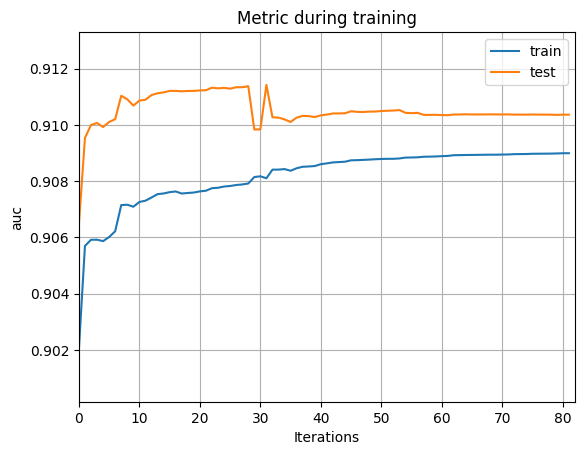

In [16]:
evals = {}

model = lgb.train(
    params=params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "test"],
    callbacks=[lgb.record_evaluation(evals), lgb.log_evaluation(10), lgb.early_stopping(stopping_rounds=50)],
    num_boost_round=1000
)

lgb.plot_metric(evals)

# Feature Importance


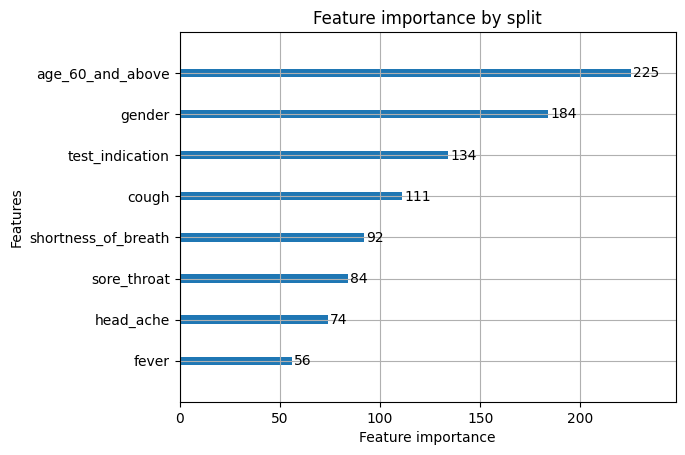

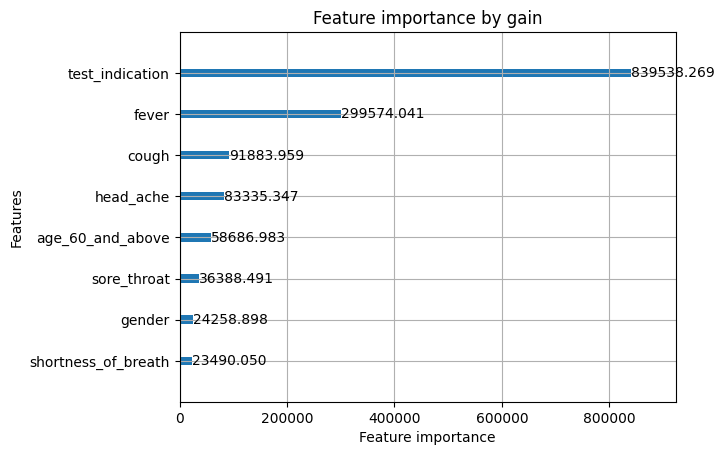

In [17]:
for imp_type in ["split", "gain"]:
    ax = lgb.plot_importance(
        model,
        importance_type=imp_type,
        dpi=100,
        title=f"Feature importance by {imp_type}",
    )

# Metrics


In [18]:
y_probs = model.predict(X_test)

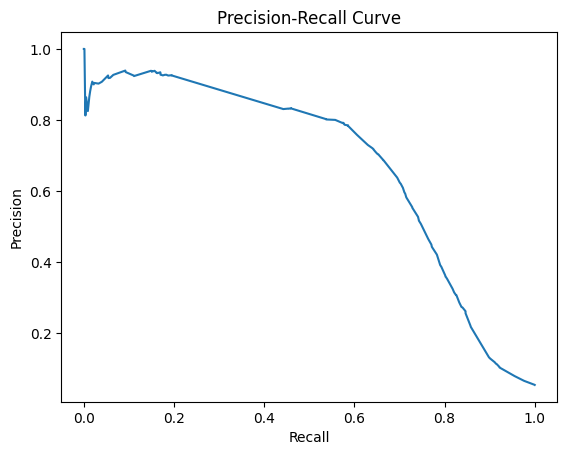

In [19]:
fig_prc, ax_prc = plt.subplots()
precision, recall, thresholds_prc = precision_recall_curve(y_test, y_probs)
ax_prc.plot(recall, precision)
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.set_title("Precision-Recall Curve")
plt.show()

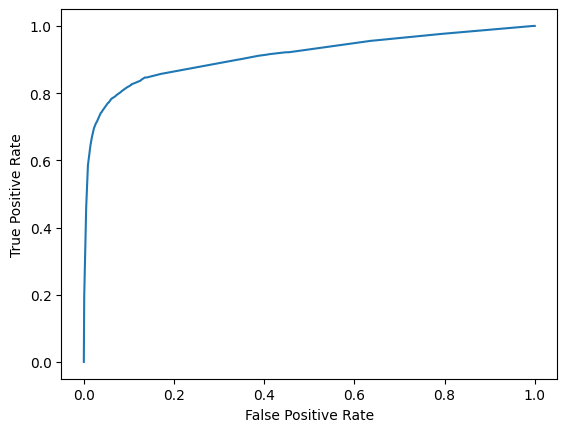

In [20]:
fig_roc, ax_roc = plt.subplots()
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
fnr = 1 - tpr
tnr = 1 - fpr
ax_roc.plot(fpr, tpr)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
plt.show()

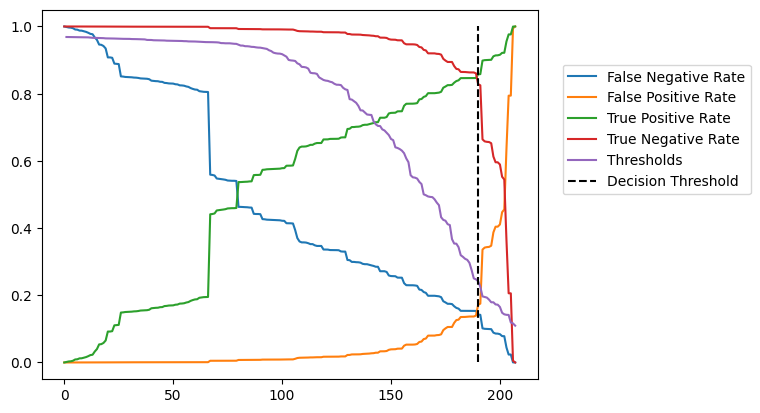

In [21]:
plt.plot(fnr, label="False Negative Rate")
plt.plot(fpr, label="False Positive Rate")
plt.plot(tpr, label="True Positive Rate")
plt.plot(tnr, label="True Negative Rate")
plt.plot(thresholds, label="Thresholds")
index_roc = np.where(fnr < fpr)[0][0]
# index_roc = 11
plt.plot(
    [index_roc, index_roc],
    [0, 1],
    color="k",
    linestyle="--",
    label="Decision Threshold",
)
plt.legend(loc=[1.05, 0.5])
plt.show()

In [22]:
threshold = thresholds[index_roc]
print(f"Threshold: {threshold:.4f}")
print(f"False Negative Rate at threshold: {fnr[index_roc]:.4f}")
print(f"False Positive Rate at threshold: {fpr[index_roc]:.4f}")

Threshold: 0.2418
False Negative Rate at threshold: 0.1426
False Positive Rate at threshold: 0.1716


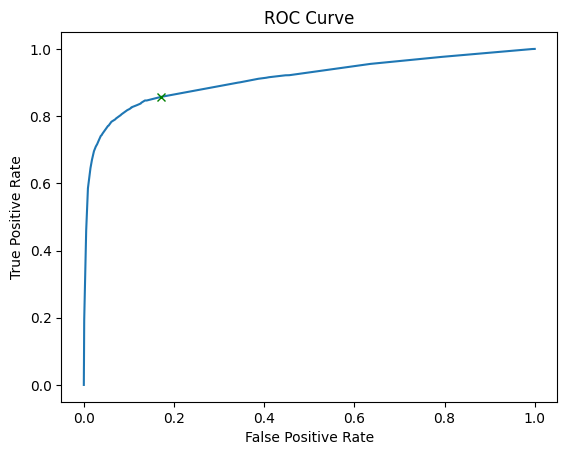

In [23]:
plt.plot(fpr, tpr)
plt.plot(fpr[index_roc], tpr[index_roc], "gx")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [24]:
auc = roc_auc_score(y_test, y_probs)
print(f"AUC: {auc:.4f}")

AUC: 0.9114


In [25]:
def predict_class(model, data, threshold=0.5):

    y_pred = model.predict(data)

    return np.where(y_pred > threshold, 1, 0)

In [26]:
y_pred = predict_class(model, X_test, threshold=threshold)

In [27]:
# print(classification_report(y_test, predict_class(model, X_test, threshold=threshold)))

# Final Model

In [28]:
# import lightgbm as lgb
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

# # 1. Prepare your data
# # X, y = your_data_loading_logic()
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# # 2. Calculate scale_pos_weight for imbalance
# # Formula: count(negative) / count(positive)
# # This forces the model to penalise missing a positive (False Negative) more heavily
# ratio = np.sum(y == 0) / np.sum(y == 1)

# # 3. Define Parameters
# params = {
#     "objective": "binary",
#     "metric": "auc",           # Directly optimising ROC-AUC
#     "is_unbalance": False,     # Use False if using scale_pos_weight (don't use both)
#     "scale_pos_weight": ratio, # High value reduces False Negatives
#     "learning_rate": 0.05,
#     "verbosity": -1,
#     "boosting_type": "gbdt"
# }

# # 4. Create Datasets
# train_data = lgb.Dataset(X_train, label=y_train)
# test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# # 5. Train
# model = lgb.train(
#     params,
#     train_data,
#     valid_sets=[test_data],
#     num_boost_round=1000,
#     callbacks=[lgb.early_stopping(stopping_rounds=50)]
# )

# 6. Optimise Threshold for False Negatives
# y_probs = model.predict(X_test)

# fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# fnr = 1 - tpr
# index_roc = np.where(fnr < fpr)[0][0]
# best_threshold = thresholds[index_roc]

# # 7. Final Predictions
# y_pred = (y_probs >= best_threshold).astype(int)

# print(f"Optimal Threshold: {best_threshold:.4f}")
# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred))


   CLASSIFICATION SUMMARY
True Positives (TP):  0.8466
True Negatives (TN):  0.8604
False Positives (FP): 0.1396  <-- Type I Error
False Negatives (FN): 0.1534  <-- Type II Error (Your Target)
------------------------------
ROC-AUC Score:        0.9114
------------------------------
Detailed Report:


              precision    recall  f1-score   support

       False       0.99      0.86      0.92     65057
        True       0.26      0.85      0.39      3682

    accuracy                           0.86     68739
   macro avg       0.62      0.85      0.66     68739
weighted avg       0.95      0.86      0.89     68739



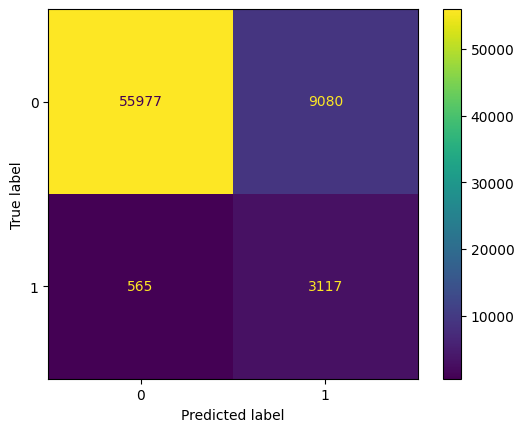

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Calculate raw counts
# .ravel() flattens the 2x2 matrix into individual variables
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Calculate Rates
total_pos = tp + fn  # All actual positive cases
total_neg = tn + fp  # All actual negative cases

tpr = tp / total_pos  # True Positive Rate (Recall / Sensitivity)
fnr = fn / total_pos  # False Negative Rate (Miss Rate) - YOUR TARGET
tnr = tn / total_neg  # True Negative Rate (Specificity)
fpr = fp / total_neg  # False Positive Rate (Fall-out)

# 2. Calculate ROC-AUC (using probabilities, not predictions)
auc_val = roc_auc_score(y_test, y_probs)

print("="*30)
print("   CLASSIFICATION SUMMARY")
print("="*30)
print(f"True Positives (TP):  {tpr:.4f}")
print(f"True Negatives (TN):  {tnr:.4f}")
print(f"False Positives (FP): {fpr:.4f}  <-- Type I Error")
print(f"False Negatives (FN): {fnr:.4f}  <-- Type II Error (Your Target)")
print("-"*30)
print(f"ROC-AUC Score:        {auc_val:.4f}")
print("-"*30)

# 3. Detailed Report (Precision, Recall, F1)
print("Detailed Report:")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()